# ISOLATION FOREST USIBG MULTIPLE TREES

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import DBSCAN
import pandas as pd

In [39]:
df=pd.read_csv("thyroid_dataset.csv")
df.tail()
# df.shape

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
6911,0.65,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0.00047,8.0000,154.0,75.0,204.0,n
6912,0.77,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00006,0.0206,125.0,107.0,117.0,n
6913,0.41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00130,25.0000,125.0,114.0,109.0,n
6914,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00078,0.0206,106.0,88.0,121.0,n
6915,0.46,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00189,0.0206,93.0,91.0,102.0,n


In [40]:
X=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [41]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [67]:
from sklearn.ensemble import IsolationForest

clf=IsolationForest(
    n_estimators=160,
    random_state=42,
)
label=clf.fit_predict(X_scaled)

In [68]:
label

array([ 1,  1, -1, ...,  1,  1,  1])

# for visualization


In [69]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)


<Axes: >

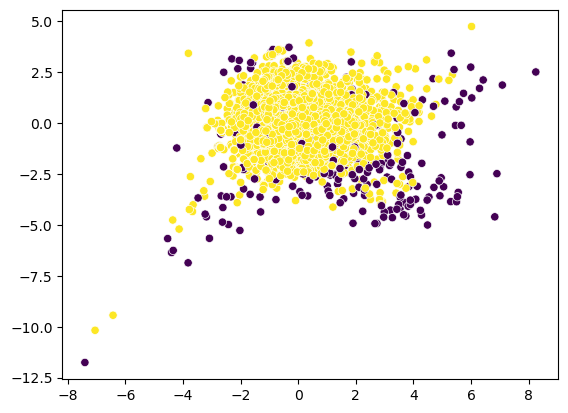

In [70]:
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    c=label,
)  


In [71]:
import numpy as np
n_outliers= np.sum(label== -1)
n_normal= np.sum(label== 1)

print(n_outliers)
print(n_normal)

264
6652
